# Generating Reference Points for Learning and Decision Phases using ADM

This notebook demonstrates how to use an ADM (Artificial Decision Maker) framework to generate reference points for both learning and decision phases in interactive multi-objective optimization. The primary goal is to create distinct sets of reference points that guide the optimization process through two critical phases:

1. **Learning Phase Reference Points**: Exploratory points that help the ADM understand the problem structure and trade-offs
2. **Decision Phase Reference Points**: Focused points that converge toward preferred solutions based on learned preferences

## Table of Contents
1. [Introduction](#1-introduction)
2. [Setup and Configuration](#2-configuration-parameters)
3. [ADM Optimization Process](#3-adm-optimization-process)
4. [Experiment Configuration Options](#4-experiment-configuration-options)
5. [Running Experiments](#5-run-experiments)
6. [Results Visualization](#6-results-visualization)

## 1. Introduction

This notebook focuses on **generating reference points** that drive interactive multi-objective optimization using the ADM framework. The core objective is to demonstrate how an artificial decision maker can systematically create two distinct types of reference points:

### Learning Phase Reference Points
- **Purpose**: Explore the objective space to understand problem characteristics
- **Behavior**: More diverse and exploratory to capture different trade-off regions
- **Iterations**: First 4 iterations (IT_LEARNING = 4)
- **Output**: Reference points that span various regions of the Pareto front

### Decision Phase Reference Points  
- **Purpose**: Converge toward preferred solutions based on accumulated knowledge
- **Behavior**: More focused and exploitative, targeting promising areas
- **Iterations**: Final 3 iterations (IT_DECISION = 3)
- **Output**: Reference points that concentrate on the most preferred trade-offs

### Technical Implementation
The notebook connects to a FastAPI-based *Problem Server* that exposes multi-objective benchmark problems (DTLZ and WFG families) through a REST API.

⚠️ **Important:** Before running this notebook, make sure the problem server (`desdeo\problem\testproblems\benchmark_server.py`) is running locally.

You can start it by opening a terminal and running:

```bash
python benchmark_server.py
```

The server should be accessible at `http://127.0.0.1:8000`.

### Process Overview
Once the server is up, this notebook will:

1. Connect to the problem server to create benchmark problem instances
2. Initialize the ADM framework with learning and decision phase configurations
3. **Generate reference points iteratively** through both phases using NSGA-III and RVEA algorithms
4. Save the generated reference points as CSV files for each phase
5. Visualize how reference points evolve from exploration (learning) to exploitation (decision)

In [1]:
import pandas as pd
from desdeo.problem import Problem
from desdeo.emo.methods.EAs import ReferenceVectorOptions
from desdeo.adm.ADMAfsar import ADMAfsar
import time
import os
from desdeo.emo.options.selection import NSGA3SelectorOptions, RVEASelectorOptions
from desdeo.emo.options.termination import MaxGenerationsTerminatorOptions
from utils import get_default_ea_parameters, create_problem

from desdeo.emo import (
    algorithms,
    generator,
    preference_handling,
)

# -- Configuration: Server URL and port
SERVER_URL = "http://127.0.0.1"
SERVER_PORT = 8000

OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IT_LEARNING = 4
IT_DECISION = 3


## 2. Configuration Parameters

The following parameters control the ADM optimization process:

### ADM Parameters
- **IT_LEARNING**: Number of learning phase iterations (4)
  - ADM explores the solution space to understand problem characteristics
- **IT_DECISION**: Number of decision phase iterations (3) 
  - ADM focuses on converging to preferred solutions

### Problem Sets
- **DTLZ Problems**: Test problems 1-7 with known Pareto fronts
- **WFG Problems**: More complex test problems 1-9 with various characteristics
- **Objective Counts**: 3, 5, and 7 objectives to test scalability

### Output Structure
All results are saved to the `results/` directory with the following naming convention:
- Reference points: `{problem_name}_{n_obj}obj_refpoints.csv`
- Algorithm iterations: `{algorithm}_iteration_{problem_name}_{n_obj}_{iteration}.csv`

## 3. ADM Optimization Process

The core function below implements the Artificial Decision Maker (ADM) framework to solve multi-objective optimization problems through iterative learning and decision phases.

## 4. Experiment Configuration Options

Before running the ADM optimization, you can choose between two experiment configurations:

### Minimal Configuration (Recommended for Testing)
- **Purpose**: Quick validation and testing of the ADM framework
- **Problems**: DTLZ1, DTLZ2 (2 problems)
- **Objectives**: 3 and 5 objectives (2 configurations)  
- **Total**: 6 experiments (~15-20 minutes)
- **Use Case**: Initial testing, debugging, or quick demonstrations

### Complete Configuration (Full Benchmark)
- **Purpose**: Comprehensive evaluation across all benchmark problems
- **Problems**: All DTLZ1-7 and WFG1-9 (16 problems)
- **Objectives**: 3, 5, and 7 objectives (3 configurations)
- **Total**: 48 experiments (more than 5 hours)
- **Use Case**: Research, publication-quality results, thorough analysis

**A dataset of a full benchmark experiment can be found in**  `full_benchmark_results.zip`

### Configuration Variables
Simply change the `EXPERIMENT_TYPE` variable in the next section:
- Set to `'minimal'` for quick testing
- Set to `'complete'` for full benchmark evaluation

In [2]:
from desdeo.emo.options.generator import LHSGeneratorOptions
from desdeo.emo.options.repair import ClipRepairOptions


def run_adm_optimization(problem: Problem) -> pd.DataFrame:
    """
    Execute ADM-based interactive optimization for a given problem.
    
    This function implements the Artificial Decision Maker (ADM) framework to solve
    multi-objective optimization problems through iterative learning and decision phases.
    
    Parameters
    ----------
    problem : Problem
        The multi-objective optimization problem instance to solve
        
    Returns
    -------
    pd.DataFrame
        DataFrame containing reference points with columns:
        - f_1, f_2, ..., f_n: Reference point coordinates for each objective
        - Phase: 'Learning' or 'Decision' phase indicator
        
    Process Overview
    ----------------
    1. Initialize ADM with learning/decision phase iterations
    2. Run initial RVEA and NSGA-III algorithms
    3. For each iteration:
       - Extract Pareto fronts from both algorithms
       - Update ADM preferences based on current fronts
       - Generate new reference points
       - Re-run algorithms with updated preferences
       - Save iteration results to CSV files
    
    Notes
    -----
    - Learning phase: IT_LEARNING iterations (default: 4)
    - Decision phase: IT_DECISION iterations (default: 3)
    - Results saved to OUTPUT_DIR with iteration-specific filenames
    """
    n_obj = len(problem.objectives)
    symbols = [f"{x.symbol}" for x in problem.objectives]
    reference_points = []
    pop_size, n_gen, pymoo_layers = get_default_ea_parameters(problem.name, n_obj)

    # Initialize ADM
    adm = ADMAfsar(
        problem=problem,
        it_learning_phase=IT_LEARNING,
        it_decision_phase=IT_DECISION,
        reference_vector_options=ReferenceVectorOptions(
            creation_type="multi_layer",
            pymoo_layers=pymoo_layers
        ),
        true_ideal=problem.get_ideal_point(),
        true_nadir=problem.get_nadir_point(),
    )

    # Initial solvers
    rvea_opts = algorithms.rvea_options()
    nsga3_opts = algorithms.nsga3_options()

    rvea_opts.template.repair = ClipRepairOptions(name="ClipRepair")
    rvea_opts.template.generator=LHSGeneratorOptions(n_points=pop_size, name='LHSGenerator')
    rvea_opts.template.termination = MaxGenerationsTerminatorOptions(name='MaxGenerationsTerminator', max_generations=n_gen)        
    rvea_opts.template.selection = RVEASelectorOptions(
        name='RVEASelector',
        reference_vector_options=ReferenceVectorOptions(
            creation_type="multi_layer",
            pymoo_layers=pymoo_layers,
        ),
        invert_reference_vectors=False
    )
    #rvea_opts.template.use_archive=False
    nsga3_opts.template.repair = ClipRepairOptions(name="ClipRepair")
    nsga3_opts.template.generator=LHSGeneratorOptions(n_points=pop_size, name='LHSGenerator')
    nsga3_opts.template.termination = MaxGenerationsTerminatorOptions(name='MaxGenerationsTerminator', max_generations=n_gen)
    nsga3_opts.template.selection = NSGA3SelectorOptions(
        name='NSGA3Selector',
        reference_vector_options=ReferenceVectorOptions(
            creation_type="multi_layer",
            pymoo_layers=pymoo_layers,
        ),
        invert_reference_vectors=False
    )
    #nsga3_opts.template.use_archive=False

    rvea, extras_rvea = algorithms.emo_constructor(
        emo_options=rvea_opts,
        problem=problem
        
    )
    nsga3, extras_nsga3 = algorithms.emo_constructor(
        emo_options=nsga3_opts,
        problem=problem
    )

    results_rvea = rvea()
    results_nsga3 = nsga3()


    iteration = 0
    while adm.has_next():
        iteration += 1
        solutions_rvea = results_rvea.optimal_variables
        solutions_nsga3 = results_nsga3.optimal_variables
        outputs_rvea = results_rvea.optimal_outputs
        outputs_nsga3 = results_nsga3.optimal_outputs

        front_rvea = results_rvea.optimal_outputs.select([symbols[i] for i in range(n_obj)]).to_numpy()
        front_nsga3 = results_nsga3.optimal_outputs.select([symbols[i] for i in range(n_obj)]).to_numpy()

        # Update ADM preference
        adm.get_next_preference(front_rvea, front_nsga3)
       
        # Determine phase
        phase = "L" if iteration <= IT_LEARNING else "D"

        # Store reference point with phase
        reference_points.append(list(adm.preference) + [phase])

        preferences_nsga3 = preference_handling.ReferencePointOptions(
            preference=dict(zip(symbols, adm.preference)),
            method="Hakanen"
        )

        preferences_rvea = preference_handling.ReferencePointOptions(
            preference=dict(zip(symbols, adm.preference)),
            method="IOPIS"
        )

        rvea_opts.template.generator = generator.ArchiveGeneratorOptions(solutions=solutions_rvea, outputs=outputs_rvea)
        nsga3_opts.template.generator = generator.ArchiveGeneratorOptions(solutions=solutions_nsga3, outputs=outputs_nsga3)

        rvea_opts.preference = preferences_rvea
        nsga3_opts.preference = preferences_nsga3

        nsga3_archive, extras_archive = algorithms.emo_constructor(
            emo_options=nsga3_opts,
            problem=problem
        )
        rvea_archive, extras_archive = algorithms.emo_constructor(
            emo_options=rvea_opts,
            problem=problem
        )

        results_nsga3 = nsga3_archive()
        results_rvea = rvea_archive()

        results_nsga3.optimal_outputs.write_csv(os.path.join(OUTPUT_DIR, f"nsga3_iteration_{problem.name}_{len(problem.objectives)}_{iteration}.csv"))
        results_rvea.optimal_outputs.write_csv(os.path.join(OUTPUT_DIR, f"rvea_iteration_{problem.name}_{len(problem.objectives)}_{iteration}.csv"))
        phase = "Learning" if iteration <= IT_LEARNING else "Decision"

    # Convert to DataFrame
    columns = [f"f_{i+1}" for i in range(n_obj)] + ["Phase"]

    df_ref = pd.DataFrame(reference_points, columns=columns)
    return df_ref

In [3]:
# 4. Run Experiments - Choose Your Configuration

from utils import get_experiment_configurations, run_experiment_batch

# Get experiment configurations
configs = get_experiment_configurations()

# ================================
# EXPERIMENT CONFIGURATION
# ================================
# Choose experiment type:
# - 'minimal': Quick test with 2 problems and 3+5 objectives (4 experiments)
# - 'complete': Full benchmark suite with all DTLZ/WFG problems and 3+5+7 objectives (48 experiments)

EXPERIMENT_TYPE = 'minimal'  # Change to 'complete' for full benchmark

print(f"ADM Configuration: {IT_LEARNING} learning + {IT_DECISION} decision iterations")
print(f"Experiment Type: {EXPERIMENT_TYPE.upper()}")

if EXPERIMENT_TYPE == 'minimal':
    print("Minimal Configuration:")
    print(f"   • DTLZ Problems: {configs['minimal']['dtlz_problems']}")
    print(f"   • WFG Problems: {configs['minimal']['wfg_problems']}")
    print(f"   • Objectives: {configs['minimal']['objective_counts']}")
    
    # Run minimal experiments
    all_problems = configs['minimal']['dtlz_problems'] + configs['minimal']['wfg_problems']
    results = run_experiment_batch(
        problems=all_problems,
        objective_counts=configs['minimal']['objective_counts'],
        run_adm_func=run_adm_optimization,
        output_dir=OUTPUT_DIR,
        experiment_type="minimal experiments"
    )
    
elif EXPERIMENT_TYPE == 'complete':
    print("Complete Configuration:")
    print(f"   • DTLZ Problems: {len(configs['complete']['dtlz_problems'])} problems (DTLZ1-7)")
    print(f"   • WFG Problems: {len(configs['complete']['wfg_problems'])} problems (WFG1-9)")
    print(f"   • Objectives: {configs['complete']['objective_counts']}")
    
    # Run complete experiments
    all_problems = configs['complete']['dtlz_problems'] + configs['complete']['wfg_problems']
    results = run_experiment_batch(
        problems=all_problems,
        objective_counts=configs['complete']['objective_counts'],
        run_adm_func=run_adm_optimization,
        output_dir=OUTPUT_DIR,
        experiment_type="complete experiments"
    )

else:
    raise ValueError(f"Unknown experiment type: {EXPERIMENT_TYPE}. Use 'minimal' or 'complete'.")

print(f"\n📊 Experiment Summary:")
print(f"   • Total runs: {results['total']}")
print(f"   • Successful: {results['successful']}")
print(f"   • Failed: {results['failed']}")
print(f"   • Duration: {results['elapsed_minutes']:.2f} minutes")

ADM Configuration: 4 learning + 3 decision iterations
Experiment Type: MINIMAL
Minimal Configuration:
   • DTLZ Problems: ['dtlz1', 'dtlz2']
   • WFG Problems: []
   • Objectives: [3, 5]
Starting minimal experiments...
Total experiments: 2 problems × 2 objective counts = 4
------------------------------------------------------------

[ 1/4] 🔄 Processing DTLZ1 with 3 objectives...
✅ Created DTLZ1 with 7 vars and 3 objectives.


C:\Users\Giomara\Documents\Projects\GECCO_journal\DESDEO\desdeo\emo\options\selection.py:114: UserWarning: Adaptation frequency was set to 0. Setting it to 100 for RVEA selector. Set it to 0 only if you provide preference information.
  return selection_types[name](problem=problem, publisher=publisher, seed=seed, verbosity=verbosity, **options)
C:\Users\Giomara\Documents\Projects\GECCO_journal\DESDEO\desdeo\emo\options\selection.py:114: UserWarning: Adaptation frequency was set to 0. Setting it to 100 for RVEA selector. Set it to 0 only if you provide preference information.
  return selection_types[name](problem=problem, publisher=publisher, seed=seed, verbosity=verbosity, **options)
C:\Users\Giomara\Documents\Projects\GECCO_journal\DESDEO\desdeo\emo\options\selection.py:114: UserWarning: Adaptation frequency was set to 0. Setting it to 100 for RVEA selector. Set it to 0 only if you provide preference information.
  return selection_types[name](problem=problem, publisher=publisher, se

         Saved 7 reference points → results\dtlz1_3obj_refpoints.csv

[ 2/4] 🔄 Processing DTLZ1 with 5 objectives...
✅ Created DTLZ1 with 9 vars and 5 objectives.


C:\Users\Giomara\Documents\Projects\GECCO_journal\DESDEO\desdeo\emo\options\selection.py:114: UserWarning: Adaptation frequency was set to 0. Setting it to 100 for RVEA selector. Set it to 0 only if you provide preference information.
  return selection_types[name](problem=problem, publisher=publisher, seed=seed, verbosity=verbosity, **options)


         Saved 7 reference points → results\dtlz1_5obj_refpoints.csv

[ 3/4] 🔄 Processing DTLZ2 with 3 objectives...
✅ Created DTLZ2 with 12 vars and 3 objectives.
         Saved 7 reference points → results\dtlz2_3obj_refpoints.csv

[ 4/4] 🔄 Processing DTLZ2 with 5 objectives...
✅ Created DTLZ2 with 14 vars and 5 objectives.
         Saved 7 reference points → results\dtlz2_3obj_refpoints.csv

[ 4/4] 🔄 Processing DTLZ2 with 5 objectives...
✅ Created DTLZ2 with 14 vars and 5 objectives.


C:\Users\Giomara\Documents\Projects\GECCO_journal\DESDEO\desdeo\emo\options\selection.py:114: UserWarning: Adaptation frequency was set to 0. Setting it to 100 for RVEA selector. Set it to 0 only if you provide preference information.
  return selection_types[name](problem=problem, publisher=publisher, seed=seed, verbosity=verbosity, **options)


         Saved 7 reference points → results\dtlz2_5obj_refpoints.csv

Minimal experiments completed in 39.96 minutes!
Successful: 4/4
Results saved to: c:\Users\Giomara\Documents\Projects\GECCO_journal\DESDEO\docs\explanation\AAC_interactive_EMO\results

📊 Experiment Summary:
   • Total runs: 4
   • Successful: 4
   • Failed: 0
   • Duration: 39.96 minutes


## 6. Results Visualization

This section creates interactive visualizations to analyze the ADM optimization process:

### For 3-Objective Problems:
- **3D Scatter Plots**: Show Pareto fronts from NSGA-III and RVEA side-by-side
- **Reference Points**: Red 'X' markers indicate ADM's preferred solutions
- **Iteration Progression**: Separate plots for each ADM iteration

### For 5+ Objective Problems:
- **Parallel Coordinates**: Handle high-dimensional objective spaces
- **Algorithm Comparison**: NSGA-III vs RVEA performance visualization

### Color Coding:
- 🟢 Green: NSGA-III solutions
- 🟣 Purple: RVEA solutions  
- 🔴 Red X: ADM reference points

### File Requirements:
The visualization expects these files in the `results/` directory:
- `{problem}_{n_obj}obj_refpoints.csv`: ADM reference points
- `nsga3_iteration_{problem}_{n_obj}_{iteration}.csv`: NSGA-III results
- `rvea_iteration_{problem}_{n_obj}_{iteration}.csv`: RVEA results

Found 4 generated experiments:
   • DTLZ1 with 3 objectives
   • DTLZ1 with 5 objectives
   • DTLZ2 with 3 objectives
   • DTLZ2 with 5 objectives

Generating visualizations...

Visualizing DTLZ1 with 3 objectives...
   Available iterations: [1, 2, 3, 4, 5, 6, 7]


<Figure size 640x480 with 0 Axes>

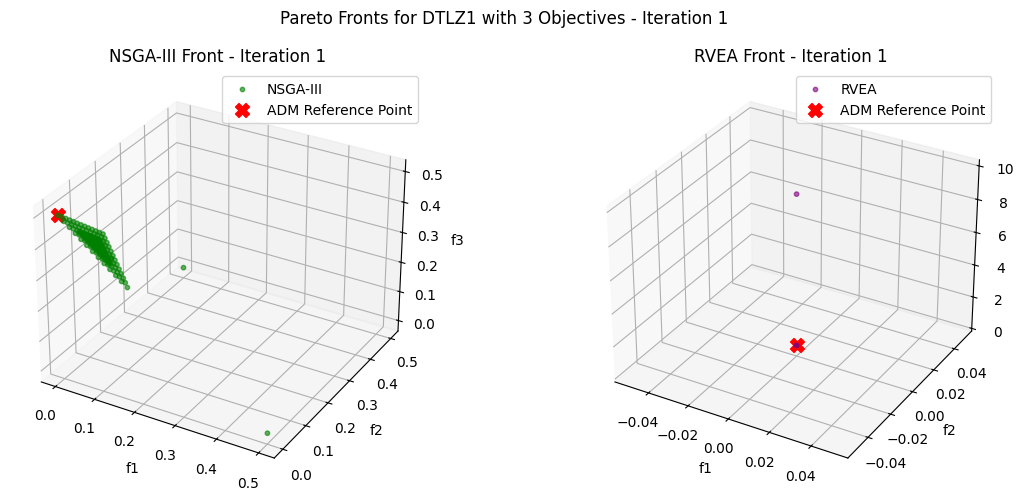

<Figure size 640x480 with 0 Axes>

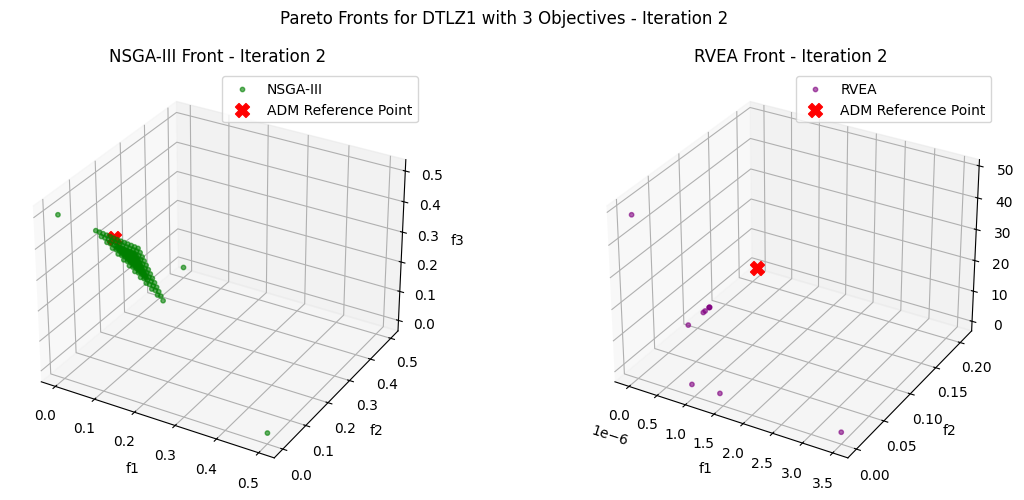

<Figure size 640x480 with 0 Axes>

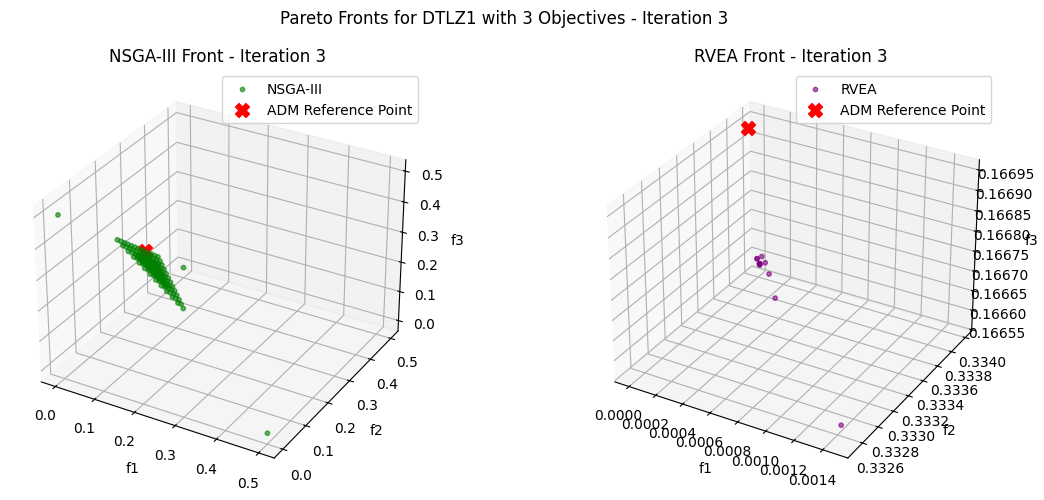

<Figure size 640x480 with 0 Axes>

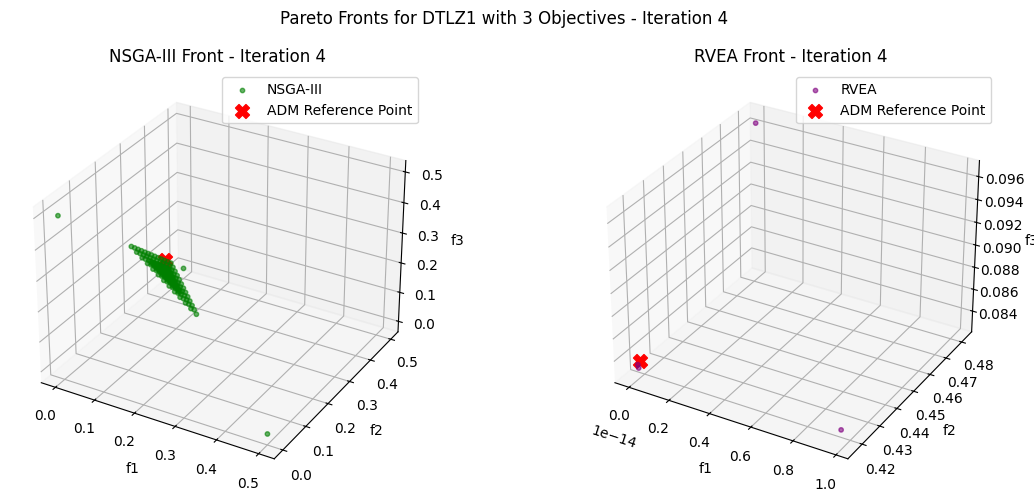

<Figure size 640x480 with 0 Axes>

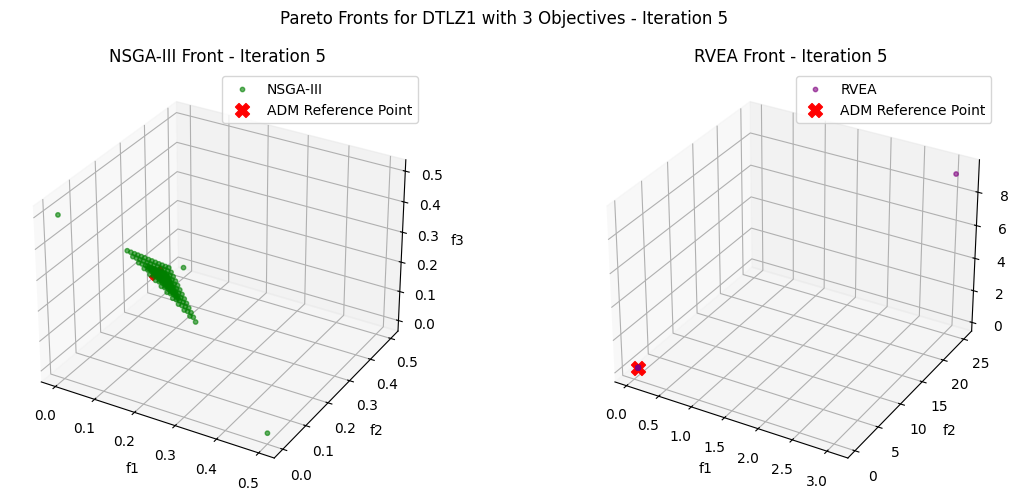

<Figure size 640x480 with 0 Axes>

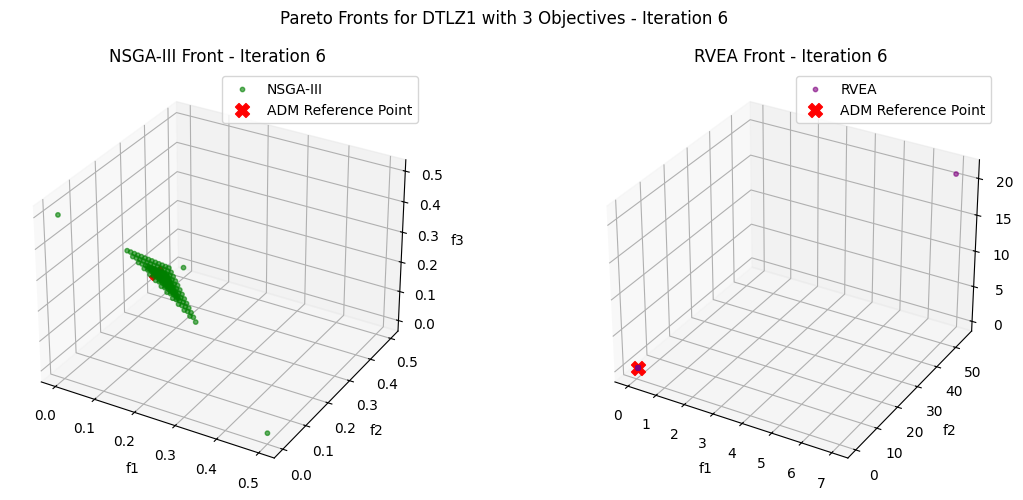

<Figure size 640x480 with 0 Axes>

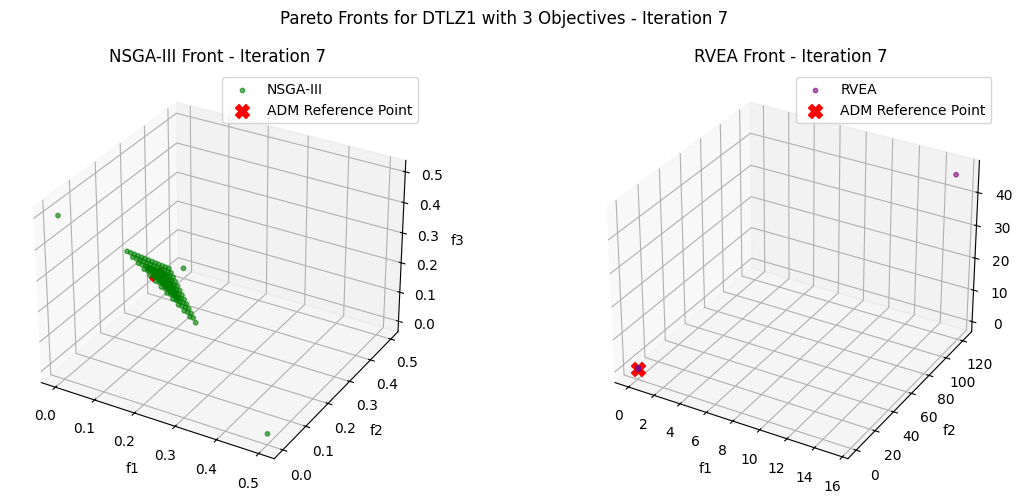

   Completed visualization for DTLZ1 with 3 objectives

Visualizing DTLZ1 with 5 objectives...
   Available iterations: [1, 2, 3, 4, 5, 6, 7]


<Figure size 640x480 with 0 Axes>

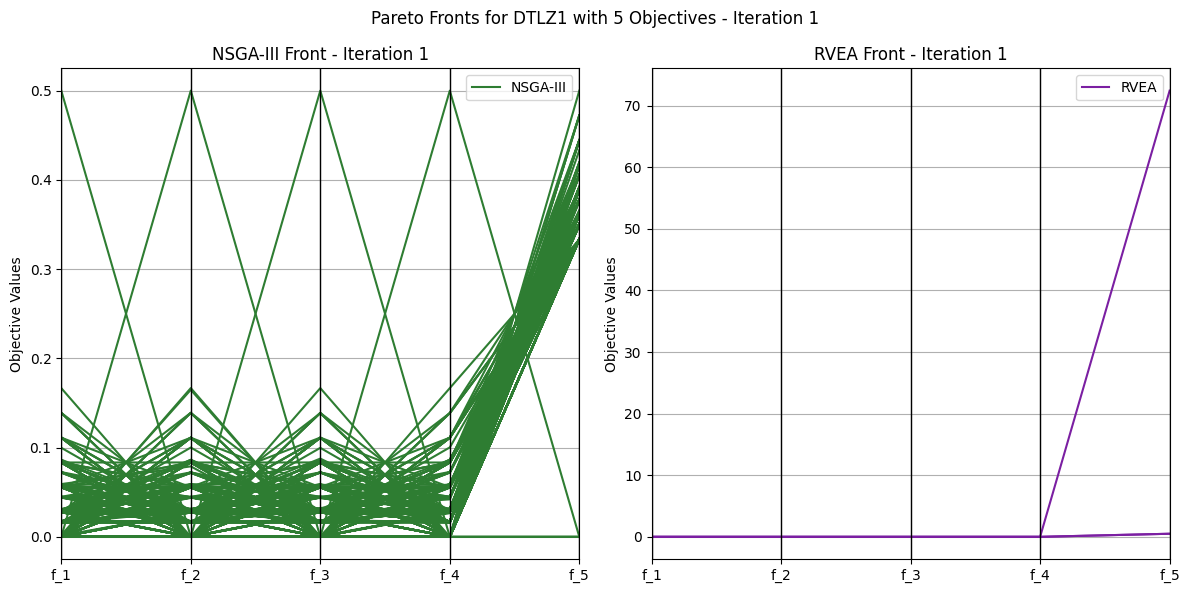

<Figure size 640x480 with 0 Axes>

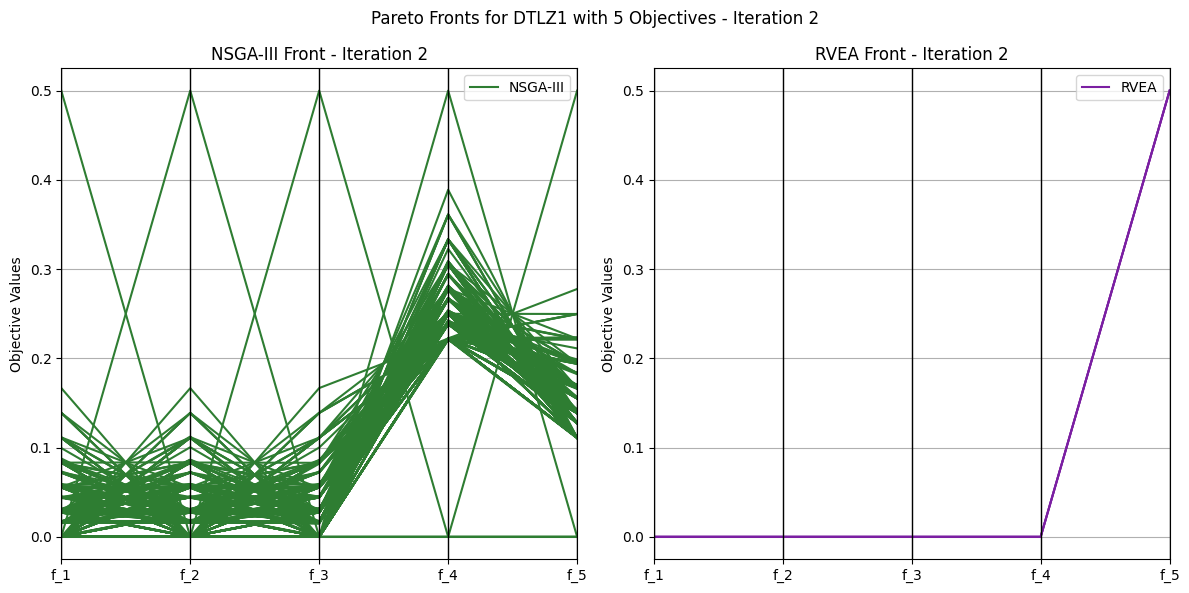

<Figure size 640x480 with 0 Axes>

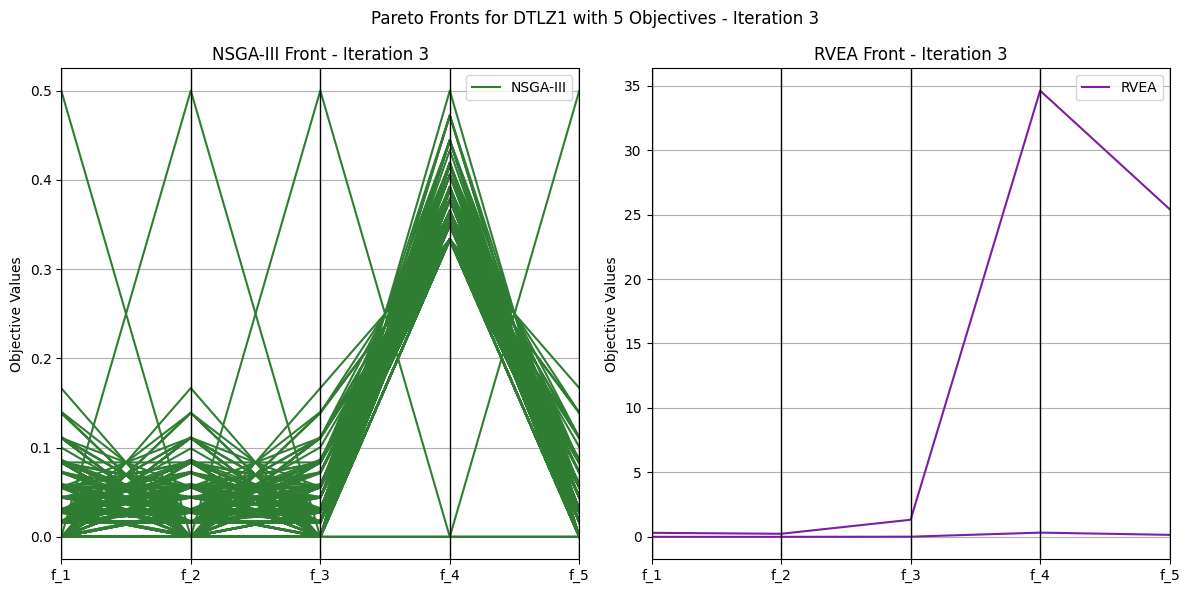

<Figure size 640x480 with 0 Axes>

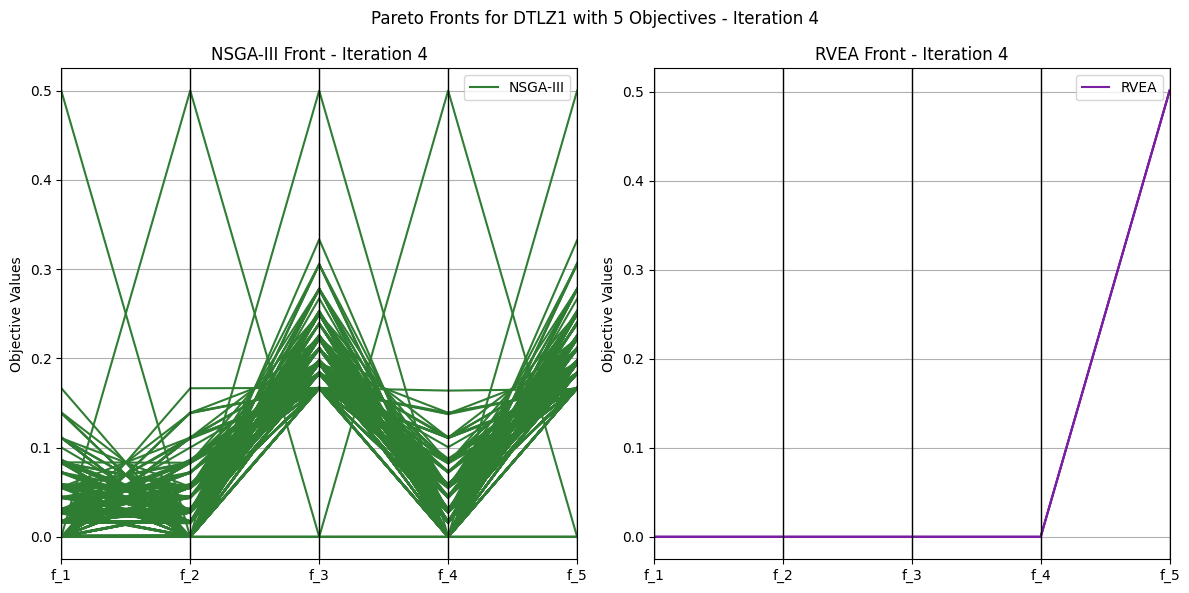

<Figure size 640x480 with 0 Axes>

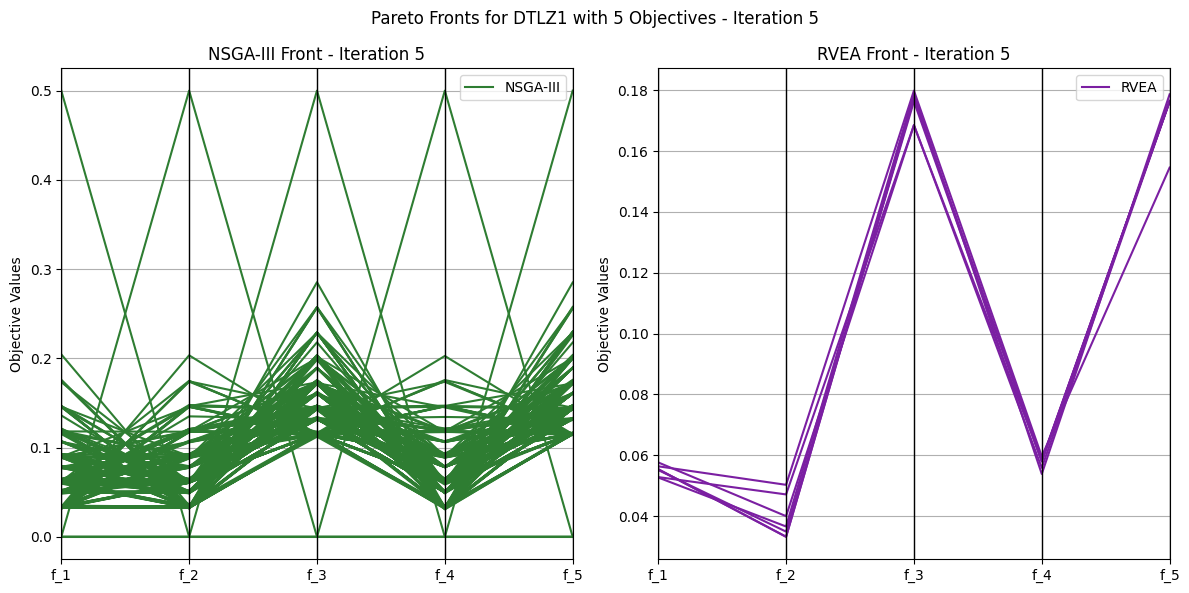

<Figure size 640x480 with 0 Axes>

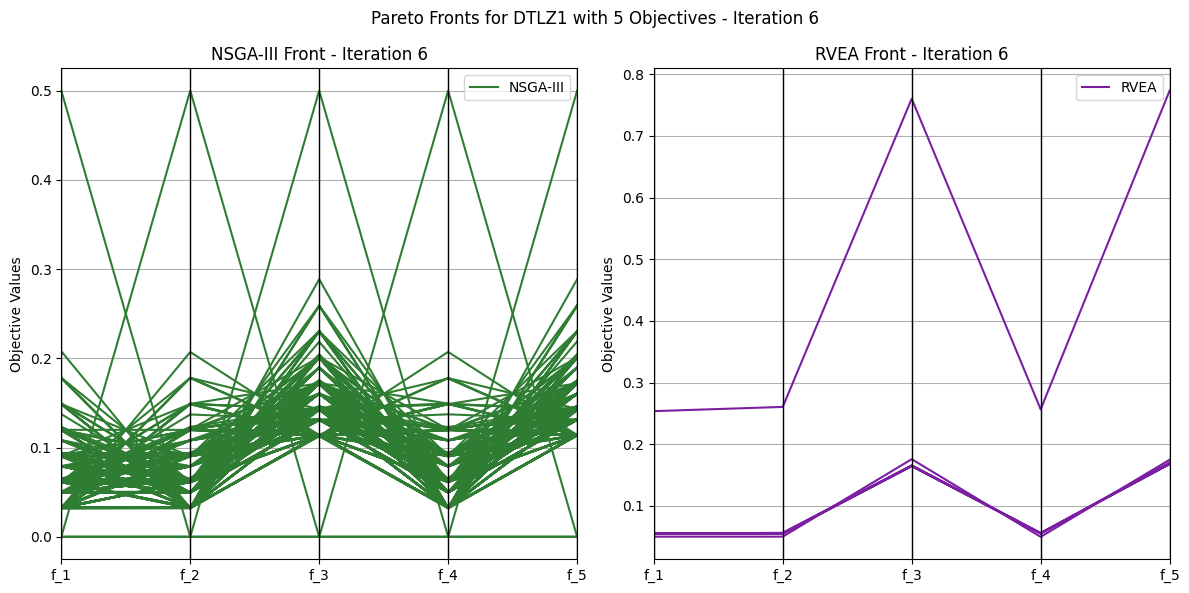

<Figure size 640x480 with 0 Axes>

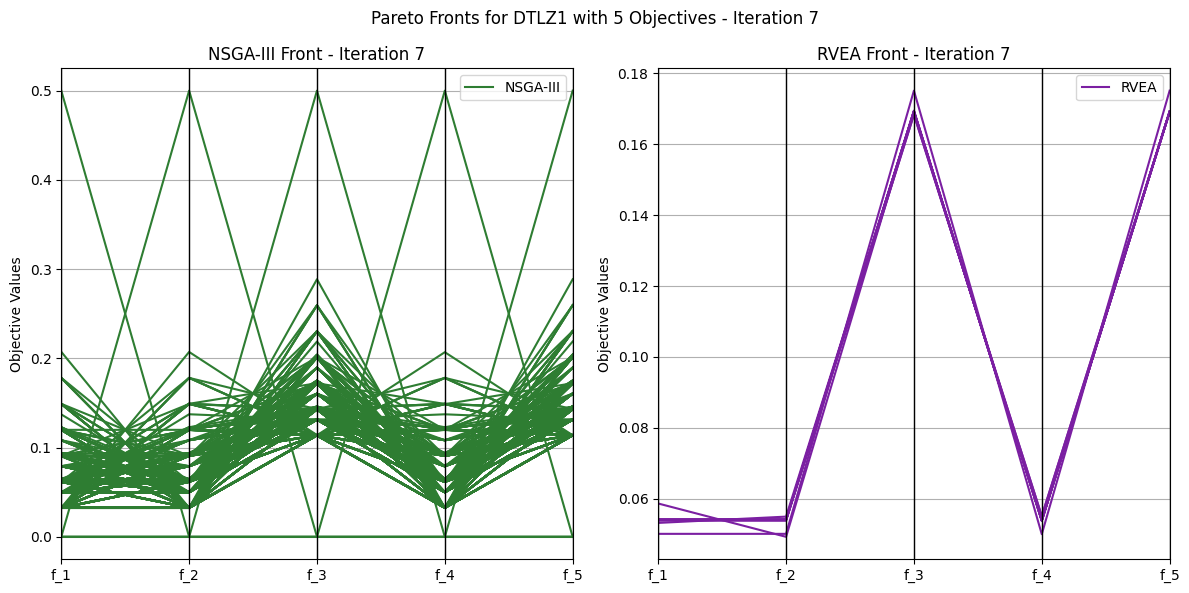

   Completed visualization for DTLZ1 with 5 objectives

Visualizing DTLZ2 with 3 objectives...
   Available iterations: [1, 2, 3, 4, 5, 6, 7]


<Figure size 640x480 with 0 Axes>

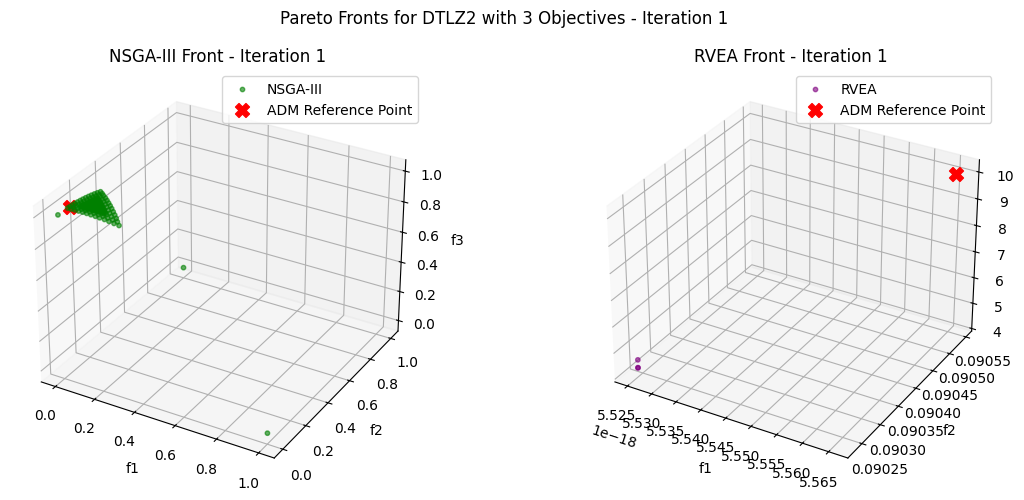

<Figure size 640x480 with 0 Axes>

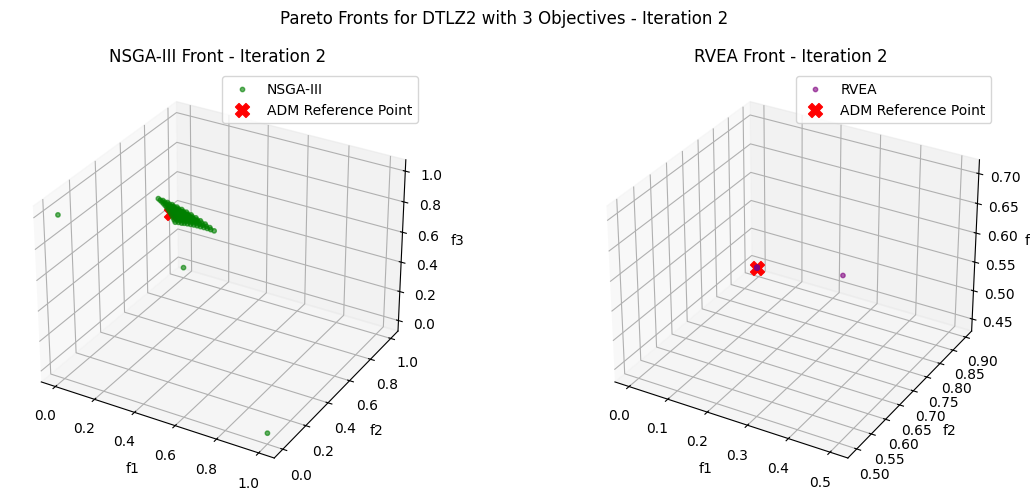

<Figure size 640x480 with 0 Axes>

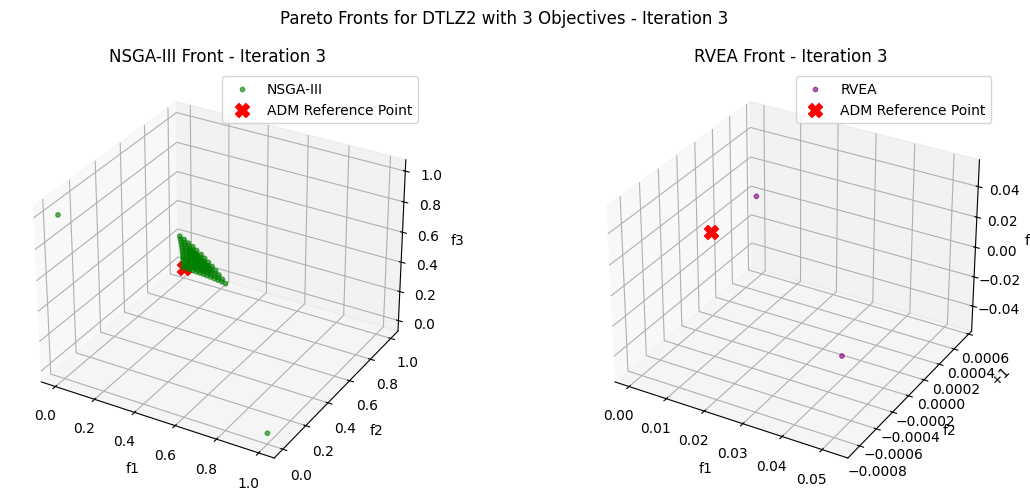

<Figure size 640x480 with 0 Axes>

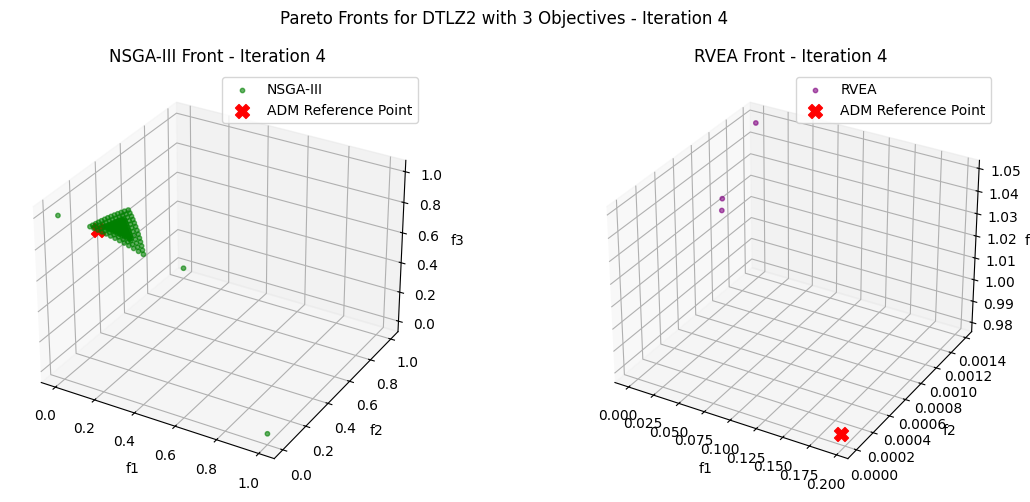

<Figure size 640x480 with 0 Axes>

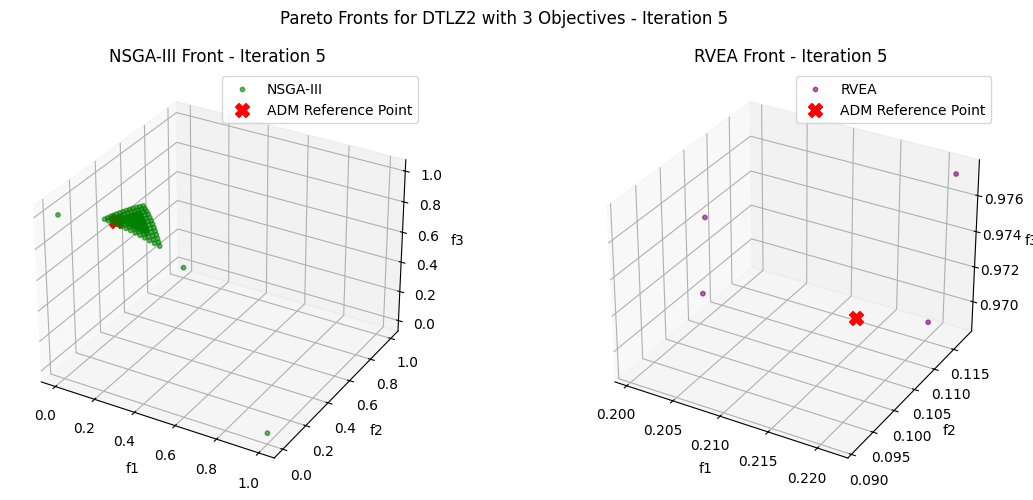

<Figure size 640x480 with 0 Axes>

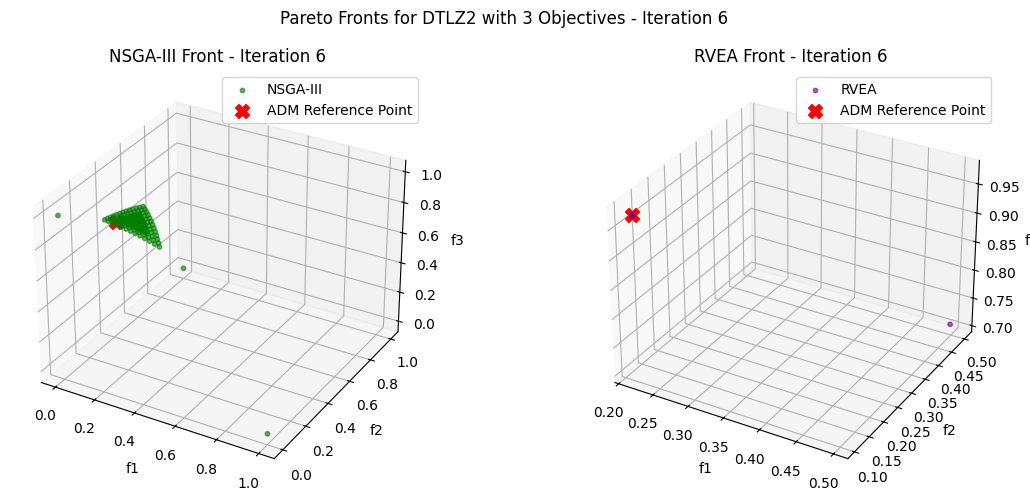

<Figure size 640x480 with 0 Axes>

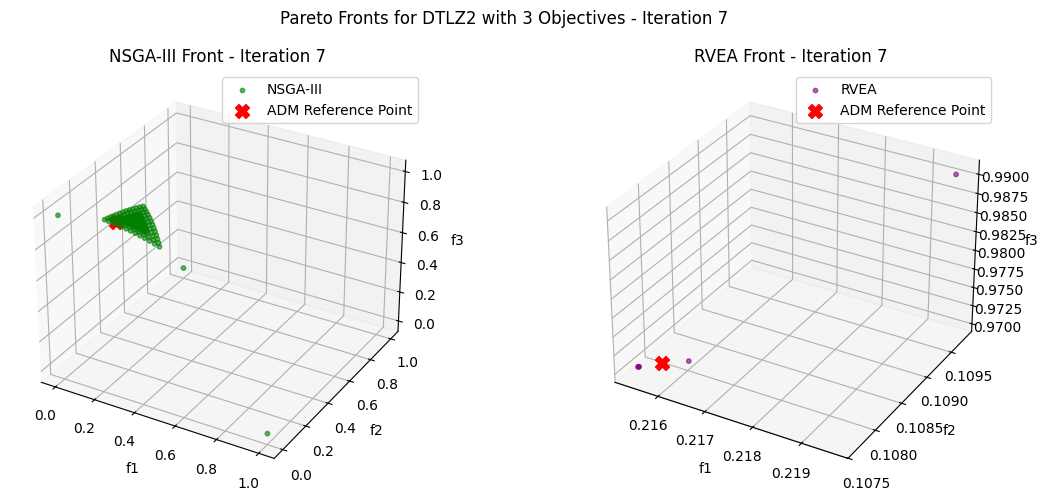

   Completed visualization for DTLZ2 with 3 objectives

Visualizing DTLZ2 with 5 objectives...
   Available iterations: [1, 2, 3, 4, 5, 6, 7]


<Figure size 640x480 with 0 Axes>

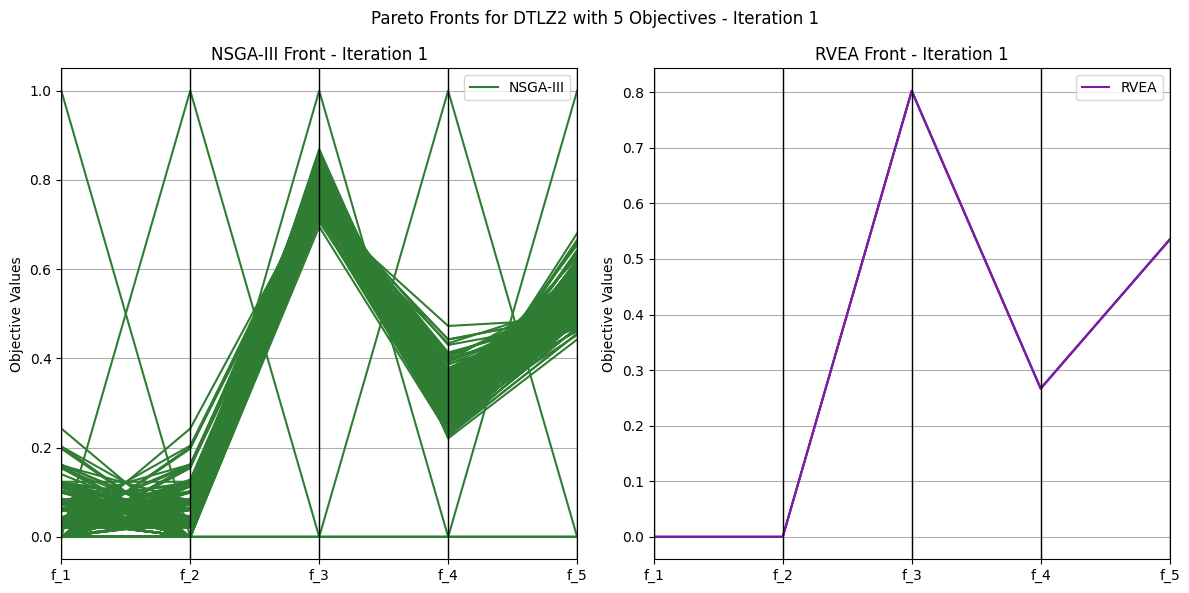

<Figure size 640x480 with 0 Axes>

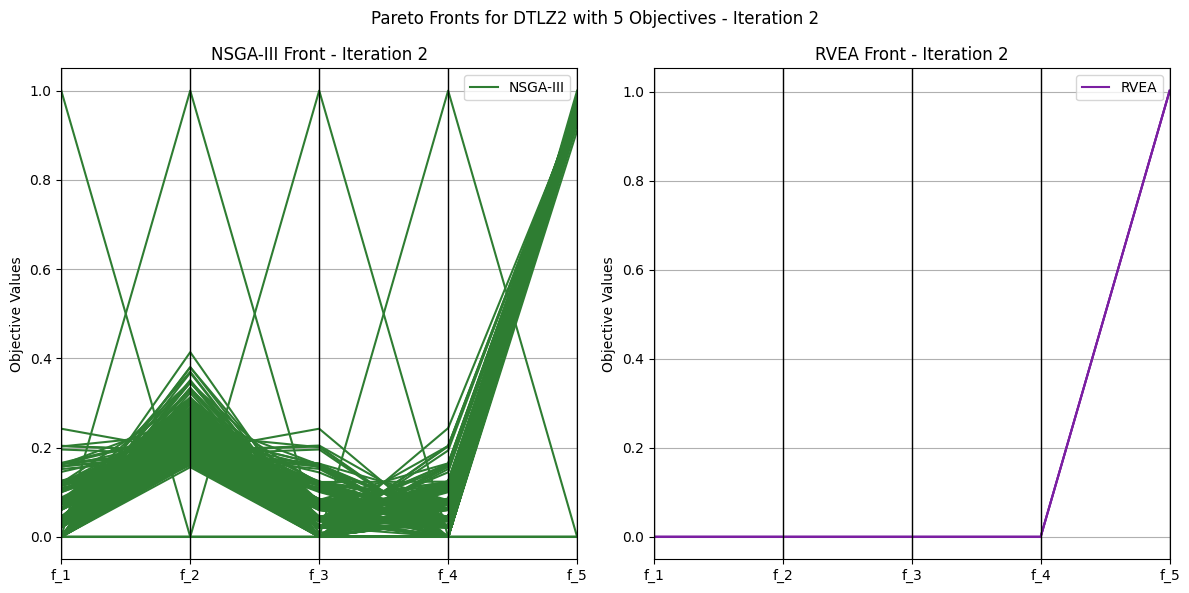

<Figure size 640x480 with 0 Axes>

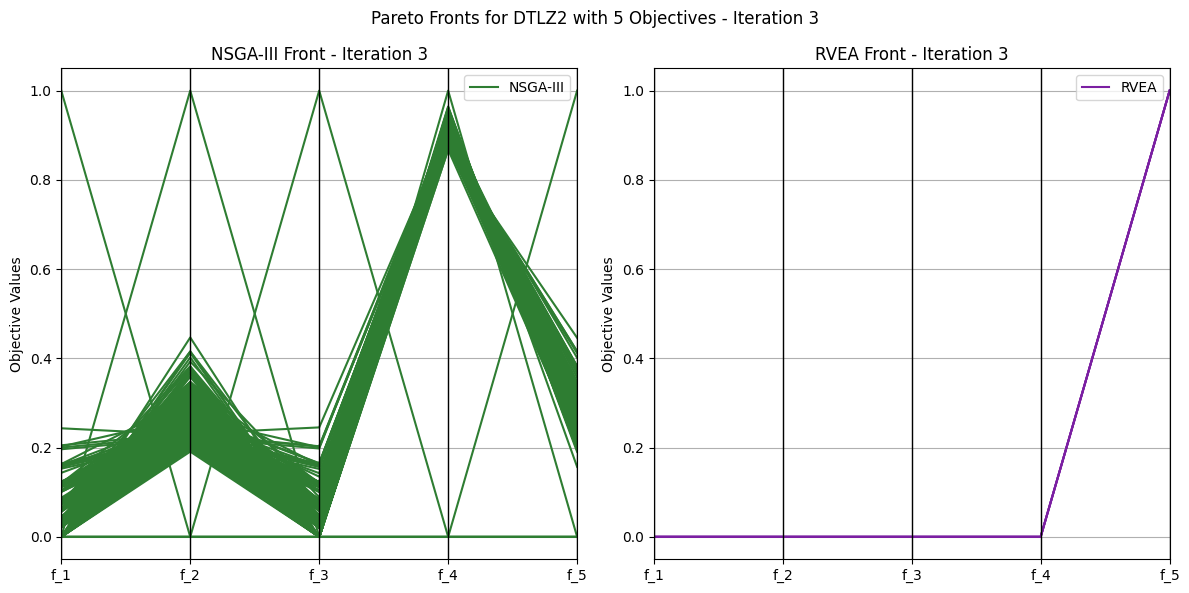

<Figure size 640x480 with 0 Axes>

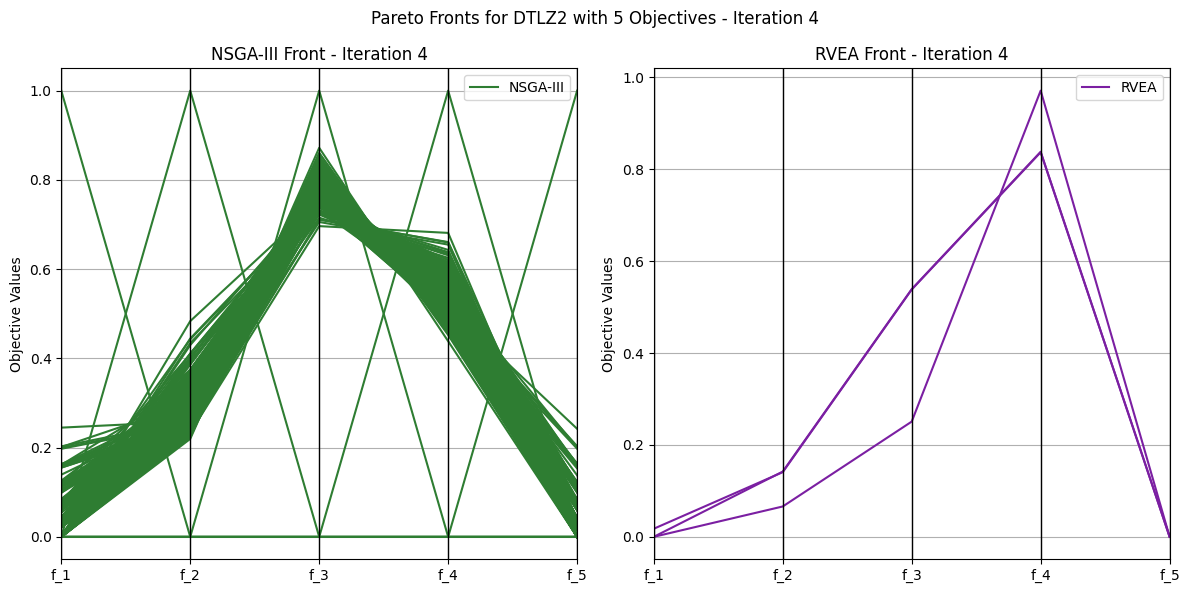

<Figure size 640x480 with 0 Axes>

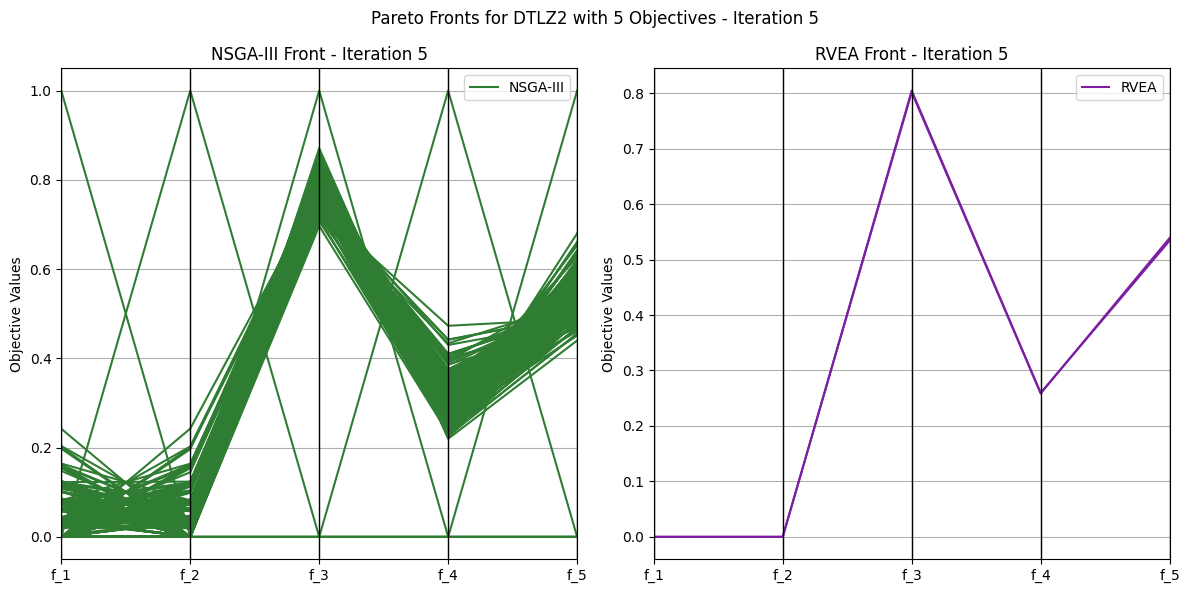

<Figure size 640x480 with 0 Axes>

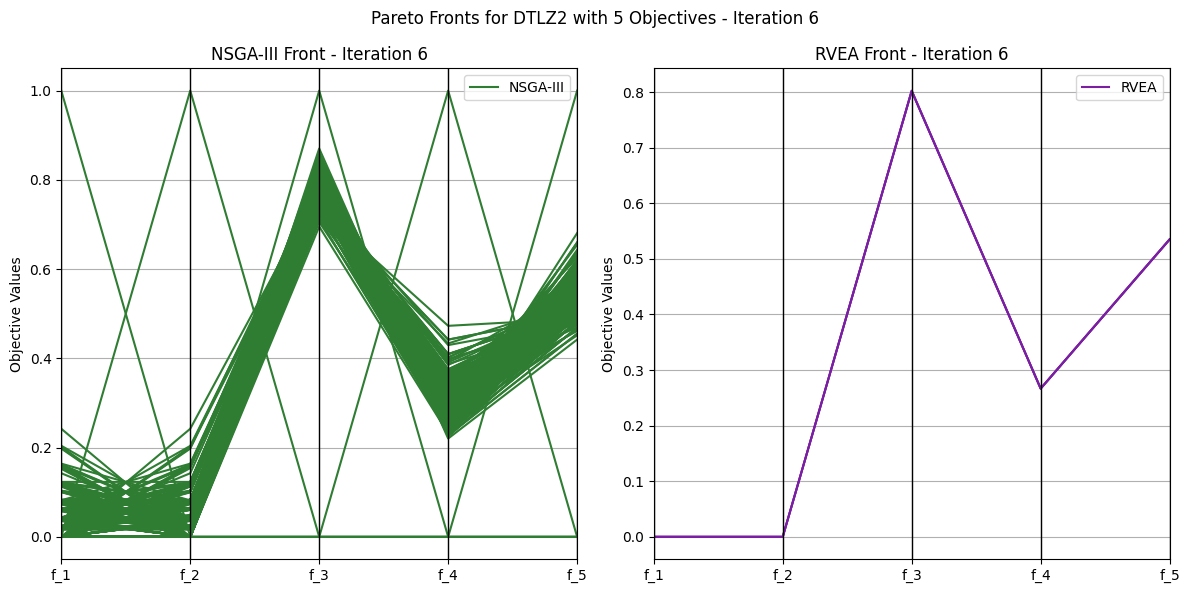

<Figure size 640x480 with 0 Axes>

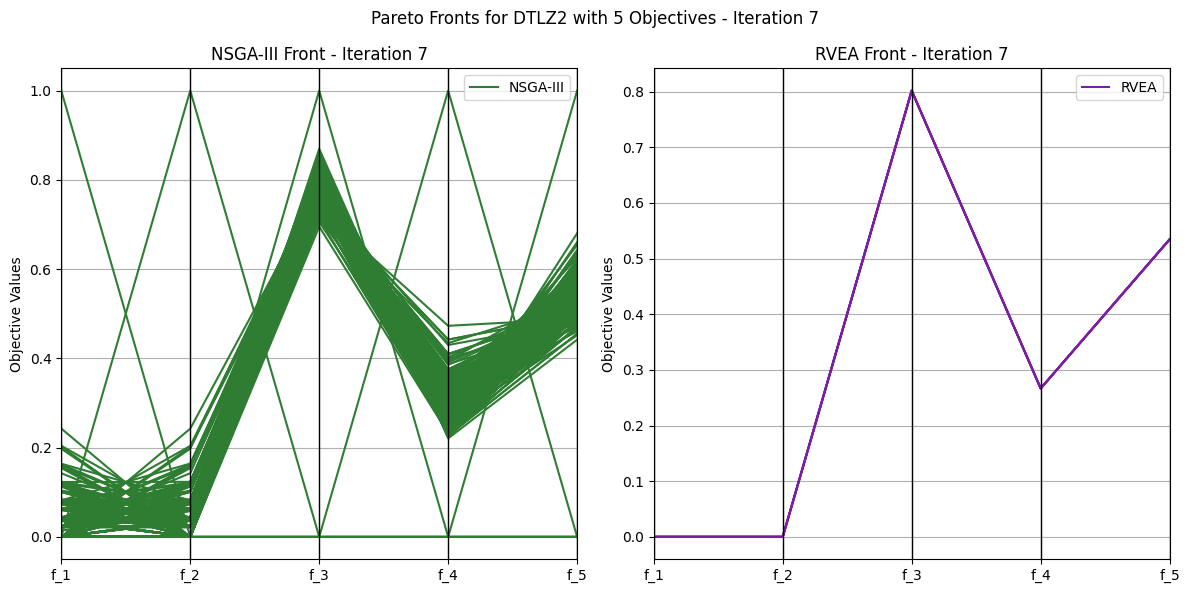

   Completed visualization for DTLZ2 with 5 objectives

All visualizations completed!


In [4]:
# Read the generated reference points and the corresponding Pareto fronts to visualize the ADM process.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
OUTPUT_DIR = "results"
import numpy as np
from utils import get_generated_experiments, check_iteration_files_exist

# Get list of successfully generated experiments
generated_experiments = get_generated_experiments(OUTPUT_DIR)

if not generated_experiments:
    print("No experiment results found in the results directory.")
    print("   Make sure to run the experiments first (Section 5).")
else:
    print(f"Found {len(generated_experiments)} generated experiments:")
    for exp in generated_experiments:
        print(f"   • {exp['name'].upper()} with {exp['n_obj']} objectives")
    print("\nGenerating visualizations...\n")

# Visualizing the results - only for generated experiments
for exp in generated_experiments:
    name = exp['name']
    n_obj = exp['n_obj']
    ref_path = exp['ref_file']
    
    print(f"Visualizing {name.upper()} with {n_obj} objectives...")
    
    reference_points = pd.read_csv(ref_path)
    phases = reference_points["Phase"].values
    prefs = reference_points.drop(columns=["Phase"]).values
    
    # Check which iteration files exist
    existing_iterations = check_iteration_files_exist(OUTPUT_DIR, name, n_obj)
    available_iterations = sorted(set(existing_iterations['nsga3']) & set(existing_iterations['rvea']))
    
    if not available_iterations:
        print(f" No matching iteration files found for {name} with {n_obj} objectives")
        continue
        
    print(f"   Available iterations: {available_iterations}")
    
    if n_obj == 3:
        # Make one plot for each available iteration
        for i, iteration in enumerate(available_iterations):
            plt.clf()
            fig = plt.figure(figsize=(12, 5))
            data_path_nsga3 = os.path.join(OUTPUT_DIR, f"nsga3_iteration_{name}_{n_obj}_{iteration}.csv")
            data_path_rvea = os.path.join(OUTPUT_DIR, f"rvea_iteration_{name}_{n_obj}_{iteration}.csv")
            
            try:
                data_nsga3 = pd.read_csv(data_path_nsga3)
                data_rvea = pd.read_csv(data_path_rvea)
            except FileNotFoundError as e:
                print(f"   Missing file for iteration {iteration}: {e}")
                continue
                
            ax = fig.add_subplot(121, projection='3d')
            ax.scatter(data_nsga3.iloc[:,0], data_nsga3.iloc[:,1],
                        data_nsga3.iloc[:,2], c='green', s=10, alpha=0.6, label='NSGA-III')
            # Draw reference point (use iteration-1 as array index since iterations start at 1)
            if iteration-1 < len(prefs):
                ax.scatter(prefs[iteration-1,0], prefs[iteration-1,1], prefs[iteration-1,2], 
                          c='red', s=100, marker='X', label='ADM Reference Point')
            ax.set_title(f'NSGA-III Front - Iteration {iteration}')
            ax.set_xlabel('f1')
            ax.set_ylabel('f2')
            ax.set_zlabel('f3')
            ax.legend()
            
            ax2 = fig.add_subplot(122, projection='3d')
            ax2.scatter(data_rvea.iloc[:,0], data_rvea.iloc[:,1], 
                        data_rvea.iloc[:,2], c='purple', s=10, alpha=0.6, label='RVEA')
            if iteration-1 < len(prefs):
                ax2.scatter(prefs[iteration-1,0], prefs[iteration-1,1], prefs[iteration-1,2], 
                           c='red', s=100, marker='X', label='ADM Reference Point')
            ax2.set_title(f'RVEA Front - Iteration {iteration}')
            ax2.set_xlabel('f1')
            ax2.set_ylabel('f2')
            ax2.set_zlabel('f3')
            ax2.legend()
            
            plt.suptitle(f'Pareto Fronts for {name.upper()} with {n_obj} Objectives - Iteration {iteration}', y=0.98)
            plt.tight_layout()
            plt.show()
            
    elif n_obj >= 5:
        # Add a parallel coordinates plot for each available iteration
        for i, iteration in enumerate(available_iterations):
            plt.clf()
            fig = plt.figure(figsize=(12, 6))
            
            data_path_nsga3 = os.path.join(OUTPUT_DIR, f"nsga3_iteration_{name}_{n_obj}_{iteration}.csv")
            data_path_rvea = os.path.join(OUTPUT_DIR, f"rvea_iteration_{name}_{n_obj}_{iteration}.csv")
            
            try:
                data_nsga3 = pd.read_csv(data_path_nsga3)
                data_rvea = pd.read_csv(data_path_rvea)
                
                # Get only the objective columns (first n_obj columns)
                data_nsga3_obj = data_nsga3.iloc[:, :n_obj]
                data_rvea_obj = data_rvea.iloc[:, :n_obj]
                
                plt.subplot(1, 2, 1)
                pd.plotting.parallel_coordinates(data_nsga3_obj.assign(Algorithm='NSGA-III'), 
                                               'Algorithm', color=('#2E7D32',))
                plt.title(f'NSGA-III Front - Iteration {iteration}')
                plt.ylabel('Objective Values')
                
                plt.subplot(1, 2, 2)
                pd.plotting.parallel_coordinates(data_rvea_obj.assign(Algorithm='RVEA'), 
                                               'Algorithm', color=('#7B1FA2',))
                plt.title(f'RVEA Front - Iteration {iteration}')
                plt.ylabel('Objective Values')
                
                plt.suptitle(f'Pareto Fronts for {name.upper()} with {n_obj} Objectives - Iteration {iteration}', y=0.98)
                plt.tight_layout()
                plt.show()
                
            except FileNotFoundError as e:
                print(f"   Missing file for iteration {iteration}: {e}")
                continue
    
    print(f"   Completed visualization for {name.upper()} with {n_obj} objectives\n")

if generated_experiments:
    print("All visualizations completed!")